# Regenerators — AIGC Detector

**TikTok TechJam 2026** · end-to-end walkthrough

This notebook runs the whole pipeline in order: environment check → datasets →
robustness transforms → the two feature branches → training → evaluation →
ablation → **sample inputs and outputs**.

## The problem

Tell AI-generated images from authentic ones, and keep working after the image
has been compressed, blurred, cropped, resized or filtered on its way through a
social platform. Clean accuracy is the easy half; the score lives in what
survives post-processing.

## The model: two branches that fail in different places

```
image ──┬──> frozen CLIP ViT-B/32 ─────> 512-d semantic embedding ──┐
        │                                                            ├─> scale ─> head ─> P(AIGC)
        └──> fixed forensic transforms ─> 143-d artifact vector ─────┘
             (FFT radial spectrum, SRM
              noise residuals, block DCT)
```

- **Semantic branch (CLIP)** — robust to degradation, but trained to match
  images to captions, so it is tuned for *content* and smooths away the fine
  detail that betrays a generator.
- **Forensic branch** — throws away content and keeps artifact statistics:
  radially-averaged FFT power spectrum (exposes the periodic grid left by
  up-convolution layers), SRM-style high-pass noise residuals from steganalysis,
  and block-DCT statistics.

Heavy blur and downscaling destroy the high frequencies the forensic branch
needs, while CLIP still recognises the image; CLIP is weakest exactly where
generator fingerprints are loudest. Fusing them means a transform that defeats
one branch usually leaves the other standing.

Both branches are **frozen** — only a small scikit-learn head is trained. ~150M
parameters (well under the 2B cap), minutes on a laptop CPU, no GPU needed.

## 1. Setup

Run this notebook with the project venv kernel from the repo root. If imports
fail, see the setup steps in the [README](../README.md).

In [2]:
%load_ext autoreload
%autoreload 2

import json
import random
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# Work from the repo root so relative data/ and models/ paths resolve.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
%cd {REPO_ROOT}

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

print("python:", sys.version.split()[0])
print("repo  :", REPO_ROOT)

/Users/hikaru/Desktop/regenerators_aigc_detector
python: 3.13.1
repo  : /Users/hikaru/Desktop/regenerators_aigc_detector


In [3]:
# Knobs for this run. Small defaults so the notebook finishes quickly on CPU --
# raise them for real numbers (see the "scaling up" note at the end).
TRAIN_PER_CLASS = 150   # source images per class, per dataset, before augmentation
TEST_PER_CLASS  = 100   # test images per class
AUGMENT_COPIES  = 2     # degraded copies per source image during training
SEED            = 42

MODEL_PATH   = Path("models/notebook_dual_branch.joblib")
REPORTS_DIR  = Path("reports/notebook")

random.seed(SEED)
np.random.seed(SEED)

def run(cmd):
    # Run a pipeline command and stream only the interesting lines.
    print(f"$ {' '.join(cmd)}\n")
    proc = subprocess.run(cmd, capture_output=True, text=True)
    noise = ("UNEXPECTED", "Loading weights", "LOAD REPORT", "unauthenticated",
             "can be ignored", "Key ", "----", "Notes:", "torchvision")
    for line in (proc.stdout + proc.stderr).splitlines():
        if line.strip() and not any(n in line for n in noise):
            print(line)
    if proc.returncode != 0:
        raise RuntimeError(f"command failed with exit code {proc.returncode}")

PY = str(Path("venv/bin/python3")) if Path("venv/bin/python3").exists() else sys.executable
print("interpreter:", PY)

interpreter: venv/bin/python3


## 2. Datasets

Everything under `data/` is gitignored, so each person downloads locally. The
download scripts are in [`scripts/`](../scripts):

```bash
./scripts/download_cifake.sh              # full CIFAKE via Kaggle (~100k images)
./scripts/download_sid_set.sh             # SID_Set subset  (default 150/class)
./scripts/download_wildfake.sh            # WildFake subset (default 300/class)
./scripts/download_wildfake_benchmark.sh  # reserved benchmark — EVAL ONLY (§8)
```

SID_Set is ~140 GB and WildFake ~1.3 TB in full, so the scripts never download
the whole thing. They use HTTP range requests to pull only the individual images
sampled — a few hundred MB for SID_Set, a few MB for WildFake.

The first three write the same layout, so everything downstream treats them
identically:

```
data/<dataset>/{train,test}/{REAL,FAKE}/
```

The fourth is deliberately different — `data/wildfake_benchmark/eval/` only, no
`train/`. That is the organisers' reserved demo set, which must never be trained
on; section 8 covers it and the leakage guards that keep it separate.

In [4]:
from aigc_detector.utils import list_images

DATASETS = ["cifake", "sid_set", "wildfake"]

rows = []
for name in DATASETS:
    for split in ["train", "test"]:
        d = Path("data") / name / split
        if not d.exists():
            continue
        rows.append({
            "dataset": name,
            "split": split,
            "REAL": len(list_images(d / "REAL")),
            "FAKE": len(list_images(d / "FAKE")),
        })

inventory = pd.DataFrame(rows)
if inventory.empty:
    print("No datasets found. Run the download scripts above first.")
else:
    inventory["total"] = inventory["REAL"] + inventory["FAKE"]
    display(inventory)

missing = [n for n in DATASETS if not (Path("data") / n).exists()]
if missing:
    print(f"\nNot downloaded yet: {', '.join(missing)} — the notebook will use what exists.")

,dataset,split,REAL,FAKE,total
0,cifake,train,50000,50000,100000
1,cifake,test,10000,10000,20000
2,sid_set,train,120,120,240
3,sid_set,test,30,30,60
4,wildfake,train,240,240,480
5,wildfake,test,60,60,120


### What the data actually looks like

Worth looking at before trusting any number. Note the resolution gap: CIFAKE is
32×32 (CIFAR-derived), while SID_Set and WildFake are full-resolution.

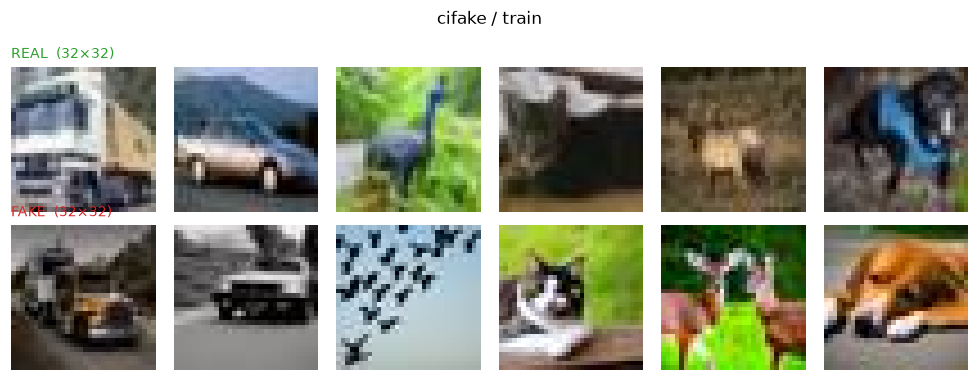

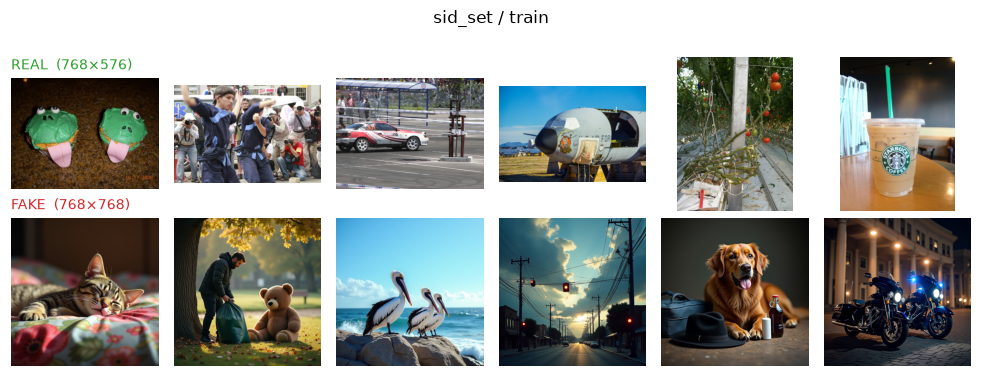

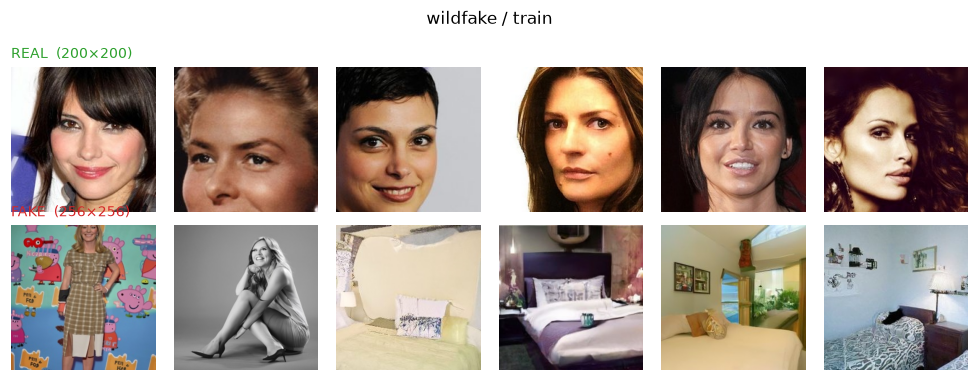

In [5]:
def show_samples(dataset, split="train", n=6):
    base = Path("data") / dataset / split
    if not base.exists():
        print(f"skipping {dataset} (not downloaded)")
        return
    fig, axes = plt.subplots(2, n, figsize=(1.5 * n, 3.4))
    for row, label in enumerate(["REAL", "FAKE"]):
        paths = list_images(base / label)[:n]
        for col in range(n):
            ax = axes[row, col]
            ax.axis("off")
            if col < len(paths):
                img = Image.open(paths[col]).convert("RGB")
                ax.imshow(img)
                if col == 0:
                    ax.set_title(f"{label}  ({img.size[0]}×{img.size[1]})",
                                 loc="left", fontsize=9,
                                 color="tab:green" if label == "REAL" else "tab:red")
    fig.suptitle(f"{dataset} / {split}", fontsize=11, y=1.0)
    plt.tight_layout()
    plt.show()

for name in DATASETS:
    show_samples(name)

> **A confound we had to fix.** In both SID_Set and WildFake the two classes ship
> in systematically different containers — real images as JPEGs at assorted
> sizes, synthetic ones as 1024×1024 PNGs. A model can score near-perfectly by
> keying on *"PNG and square"* while learning nothing about generation, then
> collapse on the first real PNG it meets. The downloaders re-encode every image
> through the same encoder at the same size cap to remove it (pass
> `--no-normalize` to measure the difference). One residual cue survives: the
> synthetic images are square and many real ones are not — we leave it, because
> cropping would destroy more signal than it removes.

## 3. The robustness transforms

These are the post-processing operations from the brief's evaluation table —
the things that happen to an image on its way through a social platform.

In [6]:
from aigc_detector.data.transforms import ROBUSTNESS_TRANSFORMS

print(f"{len(ROBUSTNESS_TRANSFORMS)} evaluation variants (including 'clean'):\n")
for name in ROBUSTNESS_TRANSFORMS:
    print(" ", name)

16 evaluation variants (including 'clean'):

  clean
  jpeg_q90
  jpeg_q70
  jpeg_q50
  jpeg_q30
  blur_sigma0.5
  blur_sigma1.0
  blur_sigma2.0
  resize_0.5x
  resize_0.25x
  noise_sigma0.02
  noise_sigma0.05
  noise_sigma0.10
  color_jitter+20%
  color_jitter-20%
  center_crop_80%


demo image from wildfake, size (256, 256)


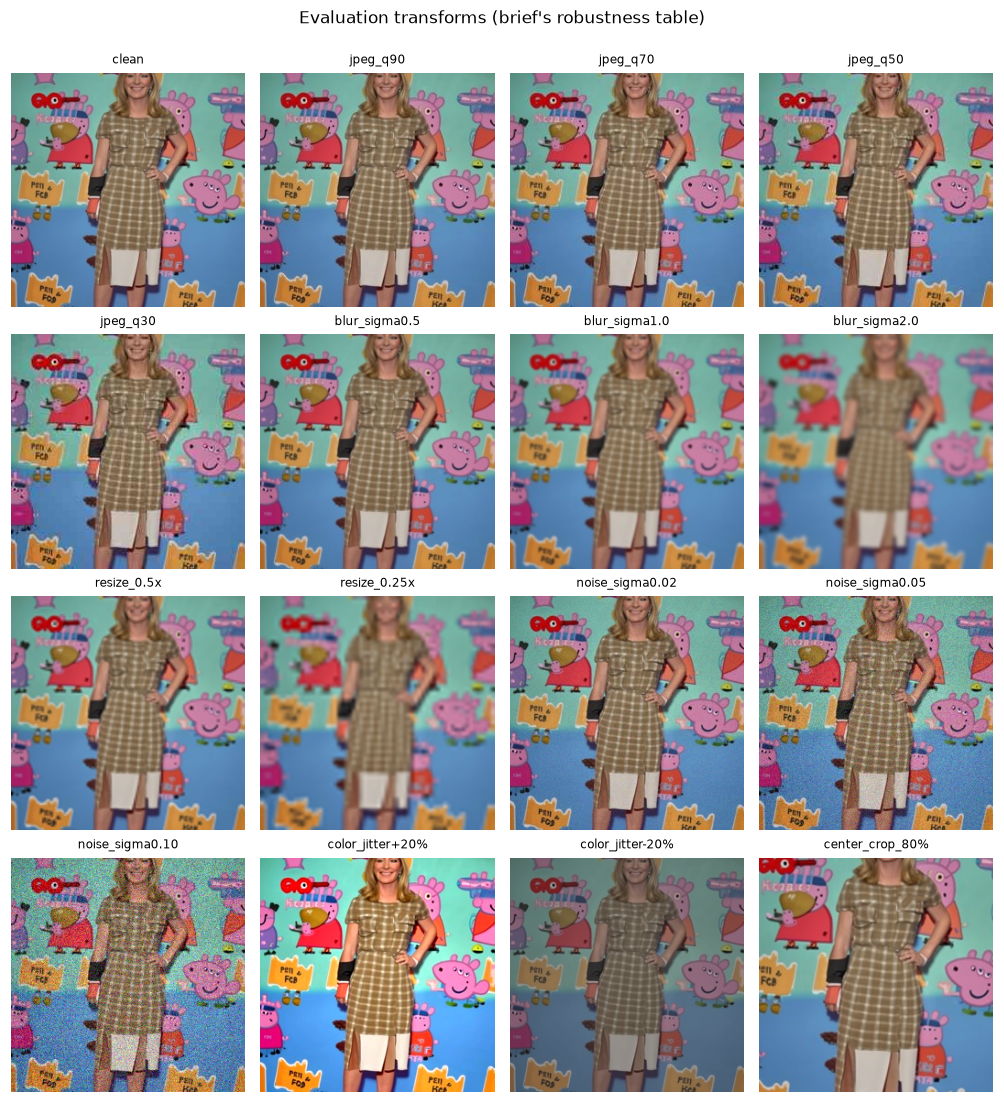

In [7]:
# Use a full-resolution image if we have one -- the effects are invisible at 32x32.
def pick_demo_image():
    for ds in ["wildfake", "sid_set", "cifake"]:
        paths = list_images(Path("data") / ds / "train" / "FAKE")
        if paths:
            return Image.open(paths[0]).convert("RGB"), ds
    raise SystemExit("No images available -- run the download scripts first.")

demo_img, demo_src = pick_demo_image()
print(f"demo image from {demo_src}, size {demo_img.size}")

items = list(ROBUSTNESS_TRANSFORMS.items())
cols = 4
rows_n = (len(items) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(2.3 * cols, 2.5 * rows_n))
for ax, (name, fn) in zip(axes.ravel(), items):
    ax.imshow(fn(demo_img))
    ax.set_title(name, fontsize=8)
    ax.axis("off")
for ax in axes.ravel()[len(items):]:
    ax.axis("off")
fig.suptitle("Evaluation transforms (brief's robustness table)", y=1.0)
plt.tight_layout()
plt.show()

### Robustness is trained in, not just measured

This is the single highest-leverage design choice in the project. The transforms
above are the *fixed* evaluation grid. For **training** we sample severities from
continuous ranges that are deliberately wider than that grid, and stack up to two
operations — so the model learns to tolerate degradation in general rather than
memorising the exact settings it will be scored on.

Each source image contributes a clean view **plus** `AUGMENT_COPIES` degraded
ones. Keeping the clean view stops the model trading away clean accuracy for
robustness — the brief scores both.

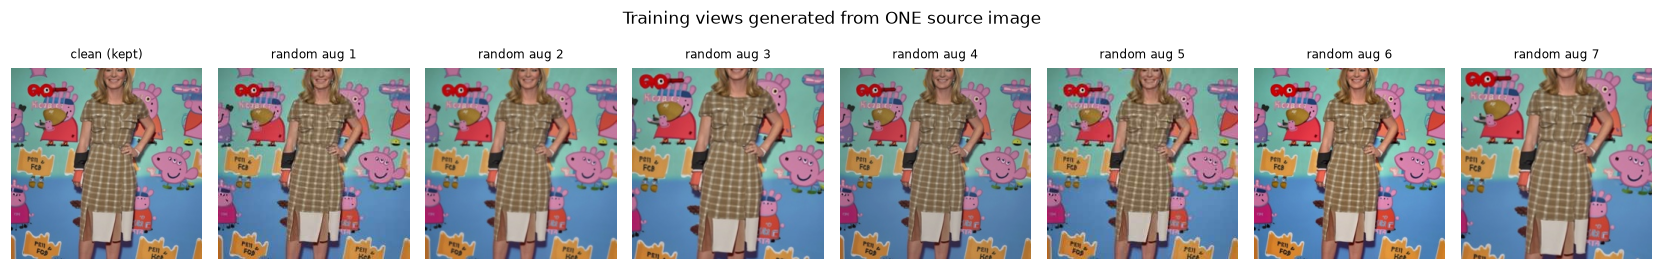

In [8]:
from aigc_detector.data.transforms import build_training_views

rng = random.Random(SEED)
views = build_training_views(demo_img, rng, n_augmented=7, keep_clean=True)

fig, axes = plt.subplots(1, len(views), figsize=(1.9 * len(views), 2.3))
for i, (ax, v) in enumerate(zip(axes, views)):
    ax.imshow(v)
    ax.set_title("clean (kept)" if i == 0 else f"random aug {i}", fontsize=8)
    ax.axis("off")
fig.suptitle("Training views generated from ONE source image", y=1.04)
plt.tight_layout()
plt.show()

## 4. Inside the forensic branch

The forensic branch is fixed signal processing — no learned parameters at all.
It contributes 143 dimensions from three families:

| Family | Dims | What it captures |
|---|---|---|
| Radial FFT power spectrum | 48 | Periodic grid artifacts from up-convolution layers |
| SRM noise residuals | 30 | Fine texture statistics; real sensor noise vs synthesis |
| Block-DCT statistics | 65 | Compression history and generator fingerprints |

The plot below is the part worth understanding: it is the azimuthally-averaged
log power spectrum, from DC (left) to Nyquist (right). If the two classes
separate at the high-frequency end, the branch has signal to work with.

forensic feature dimensionality: 143


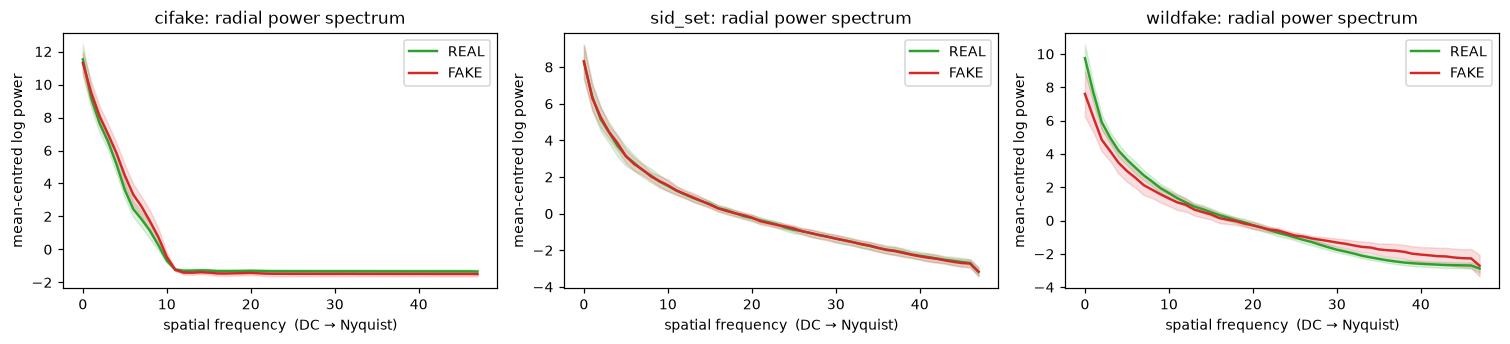

In [9]:
from aigc_detector.features.forensic import (
    FORENSIC_FEATURE_DIM,
    extract_forensic_features,
    radial_power_spectrum,
    _to_canonical_gray,
)

print("forensic feature dimensionality:", FORENSIC_FEATURE_DIM)

def spectrum_comparison(dataset, n=25):
    base = Path("data") / dataset / "train"
    if not base.exists():
        return None
    out = {}
    for label in ["REAL", "FAKE"]:
        paths = list_images(base / label)[:n]
        if not paths:
            return None
        curves = [radial_power_spectrum(_to_canonical_gray(Image.open(p).convert("RGB")))
                  for p in paths]
        out[label] = np.stack(curves)
    return out

available = [d for d in DATASETS if (Path("data") / d / "train").exists()]
fig, axes = plt.subplots(1, len(available), figsize=(4.6 * len(available), 3.2), squeeze=False)
for ax, ds in zip(axes[0], available):
    data = spectrum_comparison(ds)
    if data is None:
        ax.axis("off")
        continue
    for label, color in [("REAL", "tab:green"), ("FAKE", "tab:red")]:
        mean = data[label].mean(0)
        std = data[label].std(0)
        x = np.arange(len(mean))
        ax.plot(x, mean, color=color, label=label, lw=1.6)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)
    ax.set_title(f"{ds}: radial power spectrum")
    ax.set_xlabel("spatial frequency  (DC → Nyquist)")
    ax.set_ylabel("mean-centred log power")
    ax.legend()
plt.tight_layout()
plt.show()

Where the red and green bands pull apart — especially toward the right — is
exactly the signal CLIP is least equipped to see.

## 5. Train

Mixing datasets is what buys generalisation across generator families. CIFAKE
alone is a fast iteration loop, not a realistic proxy for social-media imagery.

Equivalent CLI:

```bash
python -m aigc_detector.train \
    --data-dir data/cifake/train --data-dir data/wildfake/train \
    --data-dir data/sid_set/train --max-per-class 150 \
    --output models/notebook_dual_branch.joblib
```

In [10]:
train_dirs = [Path("data") / d / "train" for d in DATASETS
              if (Path("data") / d / "train").exists()]

cmd = [PY, "-m", "aigc_detector.train"]
for d in train_dirs:
    cmd += ["--data-dir", str(d)]
cmd += [
    "--max-per-class", str(TRAIN_PER_CLASS),
    "--augment-copies", str(AUGMENT_COPIES),
    "--output", str(MODEL_PATH),
    "--seed", str(SEED),
]

run(cmd)   # first run downloads the CLIP weights (~600 MB), then caches them

$ venv/bin/python3 -m aigc_detector.train --data-dir data/cifake/train --data-dir data/sid_set/train --data-dir data/wildfake/train --max-per-class 150 --augment-copies 2 --output models/notebook_dual_branch.joblib --seed 42

Loaded 300 source images from data/cifake/train
Loaded 240 source images from data/sid_set/train
Loaded 300 source images from data/wildfake/train
Training views: 2520 (1260 REAL / 1260 FAKE), augment-copies=2, branches=clip+forensic
Extracting features and fitting head...
Saved classifier to models/notebook_dual_branch.joblib


## 6. Evaluate robustness

Scores the held-out test set clean **and** under every transform, then writes
`robustness_summary.csv` / `.md` and `error_analysis.json`.

**On the operating threshold.** Accuracy at a 0.5 cutoff is a weak summary for a
moderation system: wrongly flagging a real user's photo is the more expensive
mistake, so the two error types should not be traded one-for-one. The evaluator
also picks the threshold that holds the false-positive rate at or below 5% on
clean data, and reports every transform at that same fixed threshold.
`recall@fixed_thr` is the number to watch — how much AIGC we still catch at a
false-positive rate a platform could actually live with.

In [11]:
EVAL_DATASET = "cifake"   # try "wildfake" or "sid_set" for full-resolution imagery

run([
    PY, "-m", "aigc_detector.evaluate",
    "--data-dir", f"data/{EVAL_DATASET}/test",
    "--checkpoint", str(MODEL_PATH),
    "--max-per-class", str(TEST_PER_CLASS),
    "--output-dir", str(REPORTS_DIR),
    "--seed", str(SEED),
])

$ venv/bin/python3 -m aigc_detector.evaluate --data-dir data/cifake/test --checkpoint models/notebook_dual_branch.joblib --max-per-class 100 --output-dir reports/notebook --seed 42

Loaded 200 test images from data/cifake/test
Model branches: clip+forensic
Fixed operating threshold @ 5% clean FPR: 0.9819
  clean              acc=0.825  auroc=0.907  recall@fixed=0.590
  jpeg_q90           acc=0.830  auroc=0.906  recall@fixed=0.560
  jpeg_q70           acc=0.830  auroc=0.906  recall@fixed=0.570
  jpeg_q50           acc=0.795  auroc=0.890  recall@fixed=0.450
  jpeg_q30           acc=0.775  auroc=0.881  recall@fixed=0.490
  blur_sigma0.5      acc=0.805  auroc=0.890  recall@fixed=0.510
  blur_sigma1.0      acc=0.755  auroc=0.853  recall@fixed=0.550
  blur_sigma2.0      acc=0.665  auroc=0.775  recall@fixed=0.430
  resize_0.5x        acc=0.755  auroc=0.857  recall@fixed=0.540
  resize_0.25x       acc=0.670  auroc=0.761  recall@fixed=0.390
  noise_sigma0.02    acc=0.805  auroc=0.870  recall@fi

In [12]:
summary = pd.read_csv(REPORTS_DIR / "robustness_summary.csv")
display(summary.round(4))

,variant,n,accuracy,precision,recall,f1,auroc,acc@fixed_thr,recall@fixed_thr,fpr@fixed_thr
0,clean,200,0.825,0.8571,0.78,0.8168,0.9075,0.770,0.59,0.05
1,jpeg_q90,200,0.830,0.8587,0.79,0.8229,0.9065,0.760,0.56,0.04
2,jpeg_q70,200,0.830,0.8667,0.78,0.8211,0.9059,0.770,0.57,0.03
3,jpeg_q50,200,0.795,0.8391,0.73,0.7807,0.8897,0.710,0.45,0.03
4,jpeg_q30,200,0.775,0.7723,0.78,0.7761,0.8811,0.730,0.49,0.03
5,blur_sigma0.5,200,0.805,0.8506,0.74,0.7914,0.8897,0.745,0.51,0.02
6,blur_sigma1.0,200,0.755,0.7297,0.81,0.7678,0.8532,0.765,0.55,0.02
7,blur_sigma2.0,200,0.665,0.6460,0.73,0.6854,0.7748,0.680,0.43,0.07
8,resize_0.5x,200,0.755,0.7383,0.79,0.7633,0.8573,0.750,0.54,0.04
9,resize_0.25x,200,0.670,0.6491,0.74,0.6916,0.7608,0.655,0.39,0.08


### Robustness summary — the deliverable chart

Left: absolute AUROC per condition. Right: the drop against clean, which is the
robustness story. Bars that fall off a cliff mark the transforms that hurt.

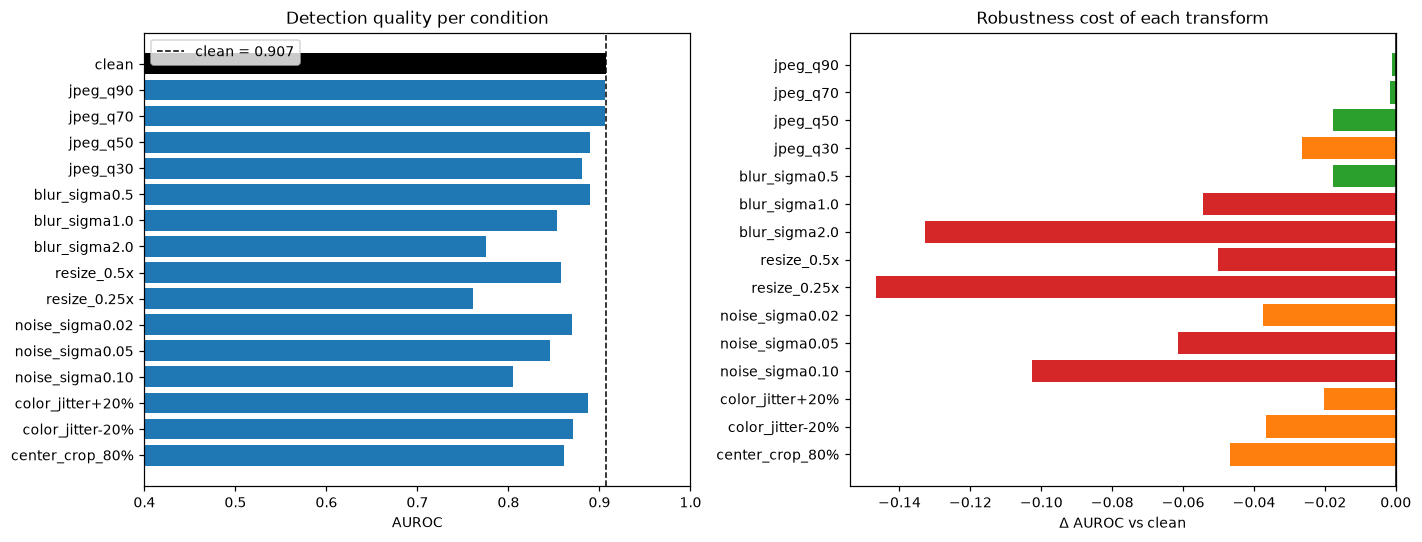

clean: accuracy=0.825  AUROC=0.907

Hardest conditions:
        variant  auroc  d_auroc
   resize_0.25x 0.7608  -0.1467
  blur_sigma2.0 0.7748  -0.1327
noise_sigma0.10 0.8048  -0.1027


In [13]:
clean_auroc = summary.loc[summary.variant == "clean", "auroc"].iloc[0]
clean_acc = summary.loc[summary.variant == "clean", "accuracy"].iloc[0]
rest = summary[summary.variant != "clean"].copy()
rest["d_auroc"] = rest["auroc"] - clean_auroc

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

colors = ["tab:blue" if v != "clean" else "black" for v in summary.variant]
ax1.barh(summary.variant, summary.auroc, color=colors)
ax1.axvline(clean_auroc, color="black", ls="--", lw=1, label=f"clean = {clean_auroc:.3f}")
ax1.set_xlabel("AUROC")
ax1.set_title("Detection quality per condition")
ax1.invert_yaxis()
ax1.set_xlim(0.4, 1.0)
ax1.legend()

ax2.barh(rest.variant, rest.d_auroc,
         color=["tab:red" if v < -0.05 else "tab:orange" if v < -0.02 else "tab:green"
                for v in rest.d_auroc])
ax2.axvline(0, color="black", lw=1)
ax2.set_xlabel("Δ AUROC vs clean")
ax2.set_title("Robustness cost of each transform")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

worst = rest.nsmallest(3, "d_auroc")[["variant", "auroc", "d_auroc"]]
print(f"clean: accuracy={clean_acc:.3f}  AUROC={clean_auroc:.3f}\n")
print("Hardest conditions:")
print(worst.to_string(index=False))

## 7. Ablation — does the fusion actually earn its place?

The dual-branch design should be justified, not assumed. Train each branch alone
and compare against the fusion on identical data.

In [14]:
ABLATION_PER_CLASS = 100   # kept small: this trains and evaluates three models

ablation_rows = []
for branches in (["clip"], ["forensic"], ["clip", "forensic"]):
    tag = "_".join(branches)
    ckpt = Path(f"models/notebook_ablation_{tag}.joblib")
    out_dir = REPORTS_DIR / f"ablation_{tag}"

    cmd = [PY, "-m", "aigc_detector.train"]
    for d in train_dirs:
        cmd += ["--data-dir", str(d)]
    cmd += ["--branches", *branches,
            "--max-per-class", str(ABLATION_PER_CLASS),
            "--augment-copies", str(AUGMENT_COPIES),
            "--output", str(ckpt), "--seed", str(SEED)]
    print(f"\n{'='*70}\nBRANCHES: {'+'.join(branches)}\n{'='*70}")
    run(cmd)

    run([PY, "-m", "aigc_detector.evaluate",
         "--data-dir", f"data/{EVAL_DATASET}/test",
         "--checkpoint", str(ckpt),
         "--max-per-class", str(TEST_PER_CLASS),
         "--output-dir", str(out_dir), "--seed", str(SEED)])

    df = pd.read_csv(out_dir / "robustness_summary.csv")
    ablation_rows.append({
        "branches": "+".join(branches),
        "clean_auroc": df.loc[df.variant == "clean", "auroc"].iloc[0],
        "mean_auroc_all": df["auroc"].mean(),
        "worst_auroc": df["auroc"].min(),
        "worst_variant": df.loc[df["auroc"].idxmin(), "variant"],
    })

ablation = pd.DataFrame(ablation_rows)
display(ablation.round(4))


BRANCHES: clip
$ venv/bin/python3 -m aigc_detector.train --data-dir data/cifake/train --data-dir data/sid_set/train --data-dir data/wildfake/train --branches clip --max-per-class 100 --augment-copies 2 --output models/notebook_ablation_clip.joblib --seed 42

Loaded 200 source images from data/cifake/train
Loaded 200 source images from data/sid_set/train
Loaded 200 source images from data/wildfake/train
Training views: 1800 (900 REAL / 900 FAKE), augment-copies=2, branches=clip
Extracting features and fitting head...
Saved classifier to models/notebook_ablation_clip.joblib
$ venv/bin/python3 -m aigc_detector.evaluate --data-dir data/cifake/test --checkpoint models/notebook_ablation_clip.joblib --max-per-class 100 --output-dir reports/notebook/ablation_clip --seed 42

Loaded 200 test images from data/cifake/test
Model branches: clip
Fixed operating threshold @ 5% clean FPR: 0.9824
  clean              acc=0.835  auroc=0.902  recall@fixed=0.620
  jpeg_q90           acc=0.825  auroc=0.906

,branches,clean_auroc,mean_auroc_all,worst_auroc,worst_variant
0,clip,0.9020,0.8591,0.7804,noise_sigma0.10
1,forensic,0.9110,0.7992,0.5976,resize_0.25x
2,clip+forensic,0.9298,0.8768,0.7853,resize_0.25x


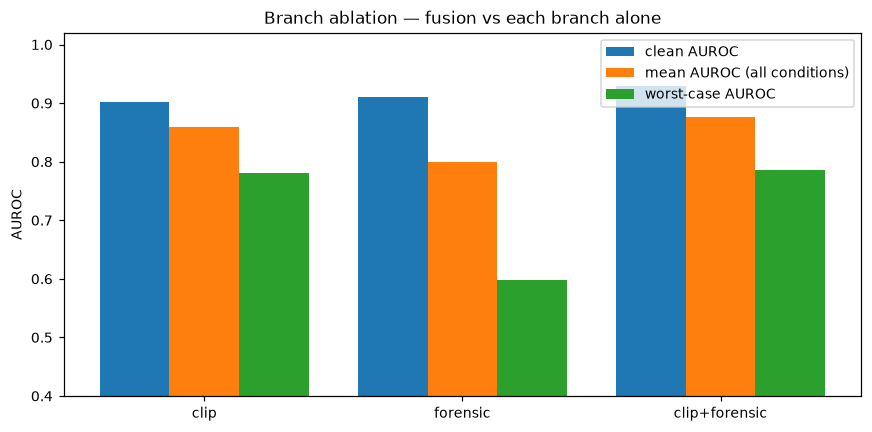

Best mean AUROC across all conditions: clip+forensic

Read the 'worst_auroc' column too -- it is the honest robustness number,
and the fusion is meant to win there even when clean AUROC is close.


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(ablation))
w = 0.27
ax.bar(x - w, ablation.clean_auroc, w, label="clean AUROC")
ax.bar(x,     ablation.mean_auroc_all, w, label="mean AUROC (all conditions)")
ax.bar(x + w, ablation.worst_auroc, w, label="worst-case AUROC")
ax.set_xticks(x)
ax.set_xticklabels(ablation.branches)
ax.set_ylabel("AUROC")
ax.set_title("Branch ablation — fusion vs each branch alone")
ax.legend()
ax.set_ylim(0.4, 1.02)
plt.tight_layout()
plt.show()

best = ablation.loc[ablation.mean_auroc_all.idxmax(), "branches"]
print(f"Best mean AUROC across all conditions: {best}")
print("\nRead the 'worst_auroc' column too -- it is the honest robustness number,")
print("and the fusion is meant to win there even when clean AUROC is close.")

## 8. The reserved benchmark — an unseen generator

Everything so far was scored on test splits drawn from the *same* datasets the
model trained on. Different images, but the same generator families — which
makes those numbers an optimistic read on deployment.

The organisers reserve a WildFake subset for exactly this reason. It is two
sources, and nothing else:

| Class | Source | Full size |
|---|---|---|
| Non-AIGC | COCO val2017 | 4998 |
| AIGC | DALL·E "Advanced" (DALL·E 3) | 8843 |

**It is demo-only: it does not count toward the final score and must never be
trained on.** Two things enforce that here rather than leaving it to discipline:

- It downloads to `data/wildfake_benchmark/` with an **`eval/` split and no
  `train/`**, so a training run that globs `data/*/train` cannot reach it.
- The training downloader takes the *complementary* slices at the source —
  `coco2017/train2017` (not `val2017`) and `DALLE/Typical` (not `Advanced`) —
  so the same image never lands on both sides.

That makes DALL·E 3 a generator the head has genuinely never seen. Expect the
numbers below to be **worse** than section 6, and treat the gap as the honest
estimate of what generalisation costs.

```bash
./scripts/download_wildfake_benchmark.sh --per-class 200
```

In [ ]:
BENCHMARK_DIR     = Path("data/wildfake_benchmark/eval")
BENCHMARK_REPORTS = REPORTS_DIR / "benchmark"

have_benchmark = BENCHMARK_DIR.exists()
if not have_benchmark:
    print("Benchmark not downloaded yet. Run:\n"
          "  ./scripts/download_wildfake_benchmark.sh --per-class 200")
else:
    n_real = len(list_images(BENCHMARK_DIR / "REAL"))
    n_fake = len(list_images(BENCHMARK_DIR / "FAKE"))
    print(f"{n_real} REAL (COCO val2017)  /  {n_fake} FAKE (DALL·E 3 Advanced)\n")

    # No --max-per-class: score everything that was downloaded.
    run([
        PY, "-m", "aigc_detector.evaluate",
        "--data-dir", str(BENCHMARK_DIR),
        "--checkpoint", str(MODEL_PATH),
        "--output-dir", str(BENCHMARK_REPORTS),
        "--seed", str(SEED),
    ])

200 REAL (COCO val2017)  /  200 FAKE (DALL·E 3 Advanced)

$ venv/bin/python3 -m aigc_detector.evaluate --data-dir data/wildfake_benchmark/eval --checkpoint models/notebook_dual_branch.joblib --output-dir reports/notebook/benchmark --seed 42



### In-distribution vs unseen generator

Same model, same transform grid, two test sets. The left bars are the test split
from section 6 (generators the model trained on); the right bars are the
reserved benchmark (DALL·E 3, never seen). The gap between them is the number
that actually predicts deployment.

In [ ]:
if not have_benchmark:
    print("Skipping — benchmark not downloaded.")
else:
    bench = pd.read_csv(BENCHMARK_REPORTS / "robustness_summary.csv")
    display(bench.round(4))

    b_clean = bench.loc[bench.variant == "clean"].iloc[0]
    print(f"benchmark clean : accuracy={b_clean.accuracy:.3f}  AUROC={b_clean.auroc:.3f}  "
          f"recall@fixed={b_clean['recall@fixed_thr']:.3f}")
    print(f"{EVAL_DATASET} clean : accuracy={clean_acc:.3f}  AUROC={clean_auroc:.3f}")
    print(f"\nAUROC gap on clean data: {b_clean.auroc - clean_auroc:+.3f}")

    # Side-by-side AUROC per transform, in-distribution vs benchmark.
    merged = summary[["variant", "auroc"]].merge(
        bench[["variant", "auroc"]], on="variant", suffixes=(f"_{EVAL_DATASET}", "_benchmark")
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    y = np.arange(len(merged))
    h = 0.38
    ax1.barh(y + h / 2, merged[f"auroc_{EVAL_DATASET}"], h,
             label=f"{EVAL_DATASET} test (seen generators)", color="tab:blue")
    ax1.barh(y - h / 2, merged["auroc_benchmark"], h,
             label="reserved benchmark (DALL·E 3)", color="tab:purple")
    ax1.set_yticks(y)
    ax1.set_yticklabels(merged.variant)
    ax1.invert_yaxis()
    ax1.set_xlim(0.4, 1.0)
    ax1.axvline(0.5, color="grey", ls=":", lw=1)
    ax1.set_xlabel("AUROC")
    ax1.set_title("Per-condition AUROC on both test sets")
    ax1.legend(fontsize=8, loc="lower right")

    delta = merged["auroc_benchmark"] - merged[f"auroc_{EVAL_DATASET}"]
    ax2.barh(merged.variant, delta,
             color=["tab:red" if d < -0.05 else "tab:orange" if d < -0.02 else "tab:green"
                    for d in delta])
    ax2.axvline(0, color="black", lw=1)
    ax2.invert_yaxis()
    ax2.set_xlabel("Δ AUROC  (benchmark − in-distribution)")
    ax2.set_title("Cost of an unseen generator")

    plt.tight_layout()
    plt.show()

## 9. Sample inputs and outputs

The required deliverable: point the detector at a directory of images and get a
JSON file of `{image_path, pred}`, where `pred` is the confidence the image is
AI-generated.

We build a small mixed directory of held-out images the model has never seen.

In [ ]:
DEMO_DIR = Path("demo_images")
DEMO_PER_CLASS = 6

import shutil
if DEMO_DIR.exists():
    shutil.rmtree(DEMO_DIR)
DEMO_DIR.mkdir(parents=True)

truth = {}
for ds in DATASETS:
    test_dir = Path("data") / ds / "test"
    if not test_dir.exists():
        continue
    for label in ["REAL", "FAKE"]:
        paths = list_images(test_dir / label)
        picked = random.Random(SEED).sample(paths, min(DEMO_PER_CLASS, len(paths)))
        for i, p in enumerate(picked):
            dest = DEMO_DIR / f"{ds}_{label.lower()}_{i}{p.suffix}"
            shutil.copy(p, dest)
            truth[dest.name] = label

print(f"{len(truth)} images staged in {DEMO_DIR}/")

36 images staged in demo_images/


In [ ]:
PRED_PATH = Path("reports/notebook/demo_predictions.json")

run([PY, "-m", "aigc_detector.infer",
     "--input-dir", str(DEMO_DIR),
     "--checkpoint", str(MODEL_PATH),
     "--output", str(PRED_PATH)])

$ venv/bin/python3 -m aigc_detector.infer --input-dir demo_images --checkpoint models/notebook_dual_branch.joblib --output reports/notebook/demo_predictions.json



Python(10600) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Found 36 images under demo_images
  scored 36/36
Wrote 36 predictions to reports/notebook/demo_predictions.json


### Sample output — the JSON the brief asks for

In [ ]:
predictions = json.loads(PRED_PATH.read_text())
print(json.dumps(predictions[:5], indent=2))
print(f"\n... {len(predictions)} entries total")

[
  {
    "image_path": "demo_images/cifake_fake_0.jpg",
    "pred": 0.1383977234363556
  },
  {
    "image_path": "demo_images/cifake_fake_1.jpg",
    "pred": 0.9999943971633911
  },
  {
    "image_path": "demo_images/cifake_fake_2.jpg",
    "pred": 0.9961000680923462
  },
  {
    "image_path": "demo_images/cifake_fake_3.jpg",
    "pred": 0.9999995231628418
  },
  {
    "image_path": "demo_images/cifake_fake_4.jpg",
    "pred": 0.9999984502792358
  }
]

... 36 entries total


### Sample inputs, with the model's confidence

Green border = model got it right, red = wrong. The number is `pred`: the
probability the image is AI-generated.

In [ ]:
pred_by_name = {Path(p["image_path"]).name: p["pred"] for p in predictions}
items = sorted(pred_by_name.items())

cols = 6
rows_n = (len(items) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(2.3 * cols, 2.9 * rows_n))
axes = np.atleast_2d(axes)

n_correct = 0
for ax, (name, pred) in zip(axes.ravel(), items):
    actual = truth[name]
    predicted = "FAKE" if pred >= 0.5 else "REAL"
    correct = predicted == actual
    n_correct += correct

    ax.imshow(Image.open(DEMO_DIR / name).convert("RGB"))
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor("tab:green" if correct else "tab:red")
        spine.set_linewidth(3)
    ax.set_title(f"truth: {actual}\npred: {pred:.3f} → {predicted}",
                 fontsize=8, color="tab:green" if correct else "tab:red")

for ax in axes.ravel()[len(items):]:
    ax.axis("off")

fig.suptitle(f"Sample inputs and outputs — {n_correct}/{len(items)} correct", y=1.0)
plt.tight_layout()
plt.show()

NameError: name 'predictions' is not defined

### Try it yourself — pick any images and score them

**Edit the settings at the top of the next cell and re-run it.** Change the
dataset, the split, which class to pull from, and which image indices to score.
The model is cached after the first run, so re-running is fast.


sid_set/test — 7/10 correct



,image,truth,pred,P(AIGC),match
0,sid_real_00120.jpg,REAL,REAL,0.0000,✓
1,sid_real_00121.jpg,REAL,REAL,0.0000,✓
2,sid_real_00122.jpg,REAL,FAKE,1.0000,✗
3,sid_real_00123.jpg,REAL,REAL,0.0031,✓
4,sid_real_00124.jpg,REAL,REAL,0.0000,✓
5,sid_fake_00120.jpg,FAKE,FAKE,0.9865,✓
6,sid_fake_00121.jpg,FAKE,FAKE,0.7131,✓
7,sid_fake_00122.jpg,FAKE,REAL,0.0984,✗
8,sid_fake_00123.jpg,FAKE,REAL,0.2133,✗
9,sid_fake_00124.jpg,FAKE,FAKE,1.0000,✓


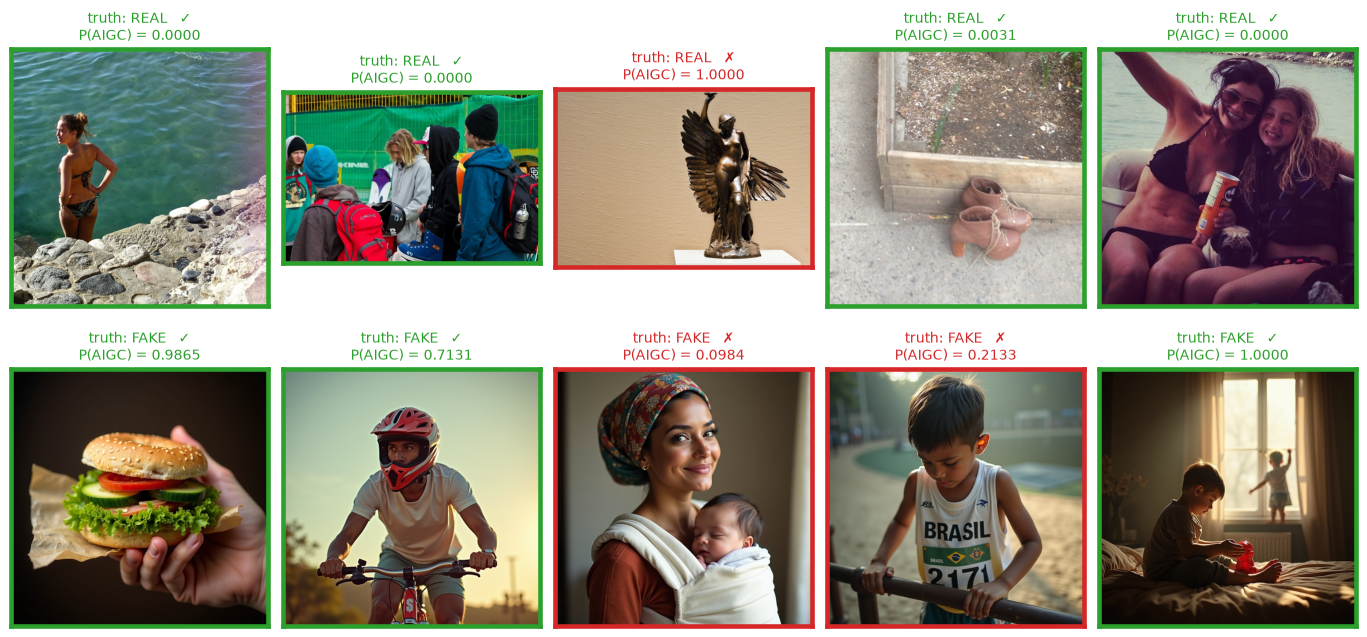

In [ ]:
# ══════════════════════════════════════════════════════════════════════
#  EDIT THESE, THEN RE-RUN THIS CELL
# ══════════════════════════════════════════════════════════════════════
DATASET = "sid_set"        # "cifake" | "sid_set" | "wildfake" | "wildfake_benchmark"
SPLIT   = "test"          # "test" | "train"  (benchmark uses "eval")
SOURCE  = "BOTH"          # "REAL" | "FAKE" | "BOTH"
INDICES = [0,1,2,3,4]  # which images, by position within each class folder
# ══════════════════════════════════════════════════════════════════════

import warnings

from transformers import logging as hf_logging

# Keep the cell output readable: the backbone's load report is expected noise
# (we load only the vision tower, so the text-encoder keys are unused).
hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore")

from aigc_detector.models.dual_branch import DualBranchClassifier

# Cache the model across re-runs so editing the settings above is snappy.
if globals().get("_cached_ckpt") != str(MODEL_PATH):
    print(f"loading {MODEL_PATH} ...")
    _cached_clf = DualBranchClassifier.load(MODEL_PATH)
    _cached_ckpt = str(MODEL_PATH)
    print(f"ready — branches: {'+'.join(_cached_clf.branches)}")

base = Path("data") / DATASET / SPLIT
if not base.exists():
    raise FileNotFoundError(f"{base} not found — check DATASET/SPLIT, or download it first.")

labels_wanted = ["REAL", "FAKE"] if SOURCE == "BOTH" else [SOURCE]

picked = []   # (path, ground_truth)
for label in labels_wanted:
    paths = list_images(base / label)
    if not paths:
        print(f"warning: no images in {base / label}")
        continue
    for i in INDICES:
        if i < len(paths):
            picked.append((paths[i], label))
        else:
            print(f"warning: index {i} out of range for {label} (only {len(paths)} images)")

if not picked:
    raise ValueError("No images selected — check INDICES.")

images = [Image.open(p).convert("RGB") for p, _ in picked]
probs = _cached_clf.predict_proba(images)

results = pd.DataFrame({
    "image": [p.name for p, _ in picked],
    "truth": [t for _, t in picked],
    "pred": ["FAKE" if pr >= 0.5 else "REAL" for pr in probs],
    "P(AIGC)": [round(float(pr), 4) for pr in probs],
})
results["match"] = np.where(results.truth == results.pred, "✓", "✗")

n_ok = int((results.truth == results.pred).sum())
print(f"\n{DATASET}/{SPLIT} — {n_ok}/{len(results)} correct\n")
display(results)

# Visual: green border = correct, red = wrong.
cols = min(5, len(picked))
rows_n = (len(picked) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(2.5 * cols, 3.1 * rows_n), squeeze=False)
for ax, (img, (path, truth), pr) in zip(axes.ravel(), zip(images, picked, probs)):
    correct = (truth == ("FAKE" if pr >= 0.5 else "REAL"))
    color = "tab:green" if correct else "tab:red"
    ax.imshow(img)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)
    ax.set_title(
        f"truth: {truth}   {'✓' if correct else '✗'}\n"
        f"P(AIGC) = {pr:.4f}",
        fontsize=9, color=color,
    )
for ax in axes.ravel()[len(picked):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

#### Score one specific image by path

For a single file — your own image, or anything outside `data/`.

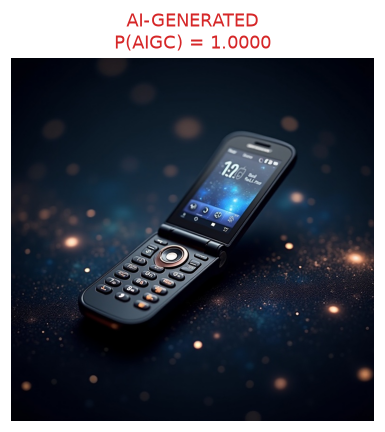

sid_set_fake_5.jpg  (768×768)
P(AIGC) = 1.0000  →  AI-GENERATED


In [ ]:
# ══════════════════════════════════════════════════════════════════════
IMAGE_PATH = "demo_images/sid_set_fake_5.jpg"   # <- any image path
# ══════════════════════════════════════════════════════════════════════

p = Path(IMAGE_PATH)
if not p.exists():
    raise FileNotFoundError(f"{p} not found")

img = Image.open(p).convert("RGB")
prob = float(_cached_clf.predict_proba([img])[0])
verdict = "AI-GENERATED" if prob >= 0.5 else "AUTHENTIC"

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(img)
ax.axis("off")
ax.set_title(f"{verdict}\nP(AIGC) = {prob:.4f}",
             fontsize=12,
             color="tab:red" if prob >= 0.5 else "tab:green")
plt.tight_layout()
plt.show()

print(f"{p.name}  ({img.size[0]}×{img.size[1]})")
print(f"P(AIGC) = {prob:.4f}  →  {verdict}")

### Where it goes wrong

Representative false positives and false negatives, ranked by how confident the
model was. False positives matter most here: flagging a real user's photo as
AI-generated carries a direct trust cost.

threshold: 0.9735  (tuned for ≤5% FPR on clean)
false positives: 5   false negatives: 30


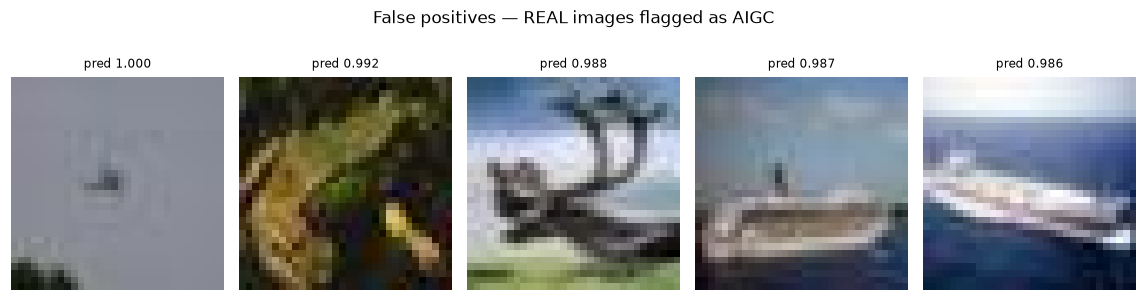

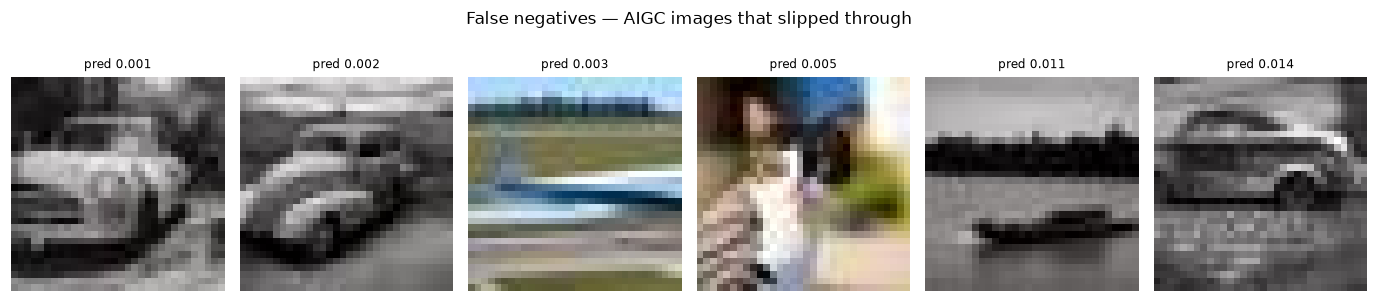

In [ ]:
errors = json.loads((REPORTS_DIR / "error_analysis.json").read_text())
print(f"threshold: {errors['threshold']:.4f}  (tuned for ≤{errors['target_fpr']:.0%} FPR on clean)")
print(f"false positives: {errors['n_false_positives']}   "
      f"false negatives: {errors['n_false_negatives']}")

def show_errors(entries, title, n=6):
    entries = entries[:n]
    if not entries:
        print(f"\n{title}: none")
        return
    fig, axes = plt.subplots(1, len(entries), figsize=(2.1 * len(entries), 2.6))
    for ax, e in zip(np.atleast_1d(axes), entries):
        ax.imshow(Image.open(e["image_path"]).convert("RGB"))
        ax.set_title(f"pred {e['pred_prob']:.3f}", fontsize=8)
        ax.axis("off")
    fig.suptitle(title, y=1.05)
    plt.tight_layout()
    plt.show()

show_errors(errors["false_positives"], "False positives — REAL images flagged as AIGC")
show_errors(errors["false_negatives"], "False negatives — AIGC images that slipped through")

## 10. Scaling up, and what we'd do next

Everything above ran on deliberately small caps so the notebook finishes on CPU.
For numbers worth quoting, raise them at the top and re-run:

| Setting | Notebook | For real results |
|---|---|---|
| `TRAIN_PER_CLASS` | 150 | 2000+ |
| `TEST_PER_CLASS` | 100 | 1000+ |
| `AUGMENT_COPIES` | 2 | 3–4 |

The reserved benchmark in section 8 scales the same way — `--per-class 0` pulls
all 4998 real / 8843 fake images:

```bash
./scripts/download_wildfake_benchmark.sh --per-class 0
```

### Known limitations

- **CIFAKE is 32×32.** CLIP expects 224×224, so those images are upscaled ~7×
  and there is little real high-frequency detail for the forensic branch to
  read. Trust the SID_Set and WildFake numbers more.
- **Frozen backbone.** Only the head trains, so accuracy is capped by what is
  linearly separable in the fused feature space.
- **Forensic blind spot.** It reads a fixed 256×256 grayscale resize, so
  aggressive downscaling and heavy blur remove the evidence it needs — visible
  in the robustness table, and exactly why the fusion exists.
- **Generator coverage.** The subsets span a handful of generator families;
  leave-one-generator-out is the metric that would really predict deployment,
  and section 8 is a single instance of it.

### Next steps

1. Fine-tune the last few CLIP blocks instead of freezing everything.
2. Measure leave-one-generator-out generalisation.
3. Calibrate the score (temperature scaling / reliability diagrams) so `pred`
   reads as a probability rather than just a ranking.
4. Patch-level scoring with aggregation, so high-resolution images are not
   bottlenecked through a single 224×224 resize.